In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from catboost import CatBoostRegressor
from sklearn.linear_model import LinearRegression, HuberRegressor
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)


In [ ]:
data = pd.read_excel('../../dataset/all data.xlsx', sheet_name='new')
groups = data['Reference'].copy()

In [3]:
data['logIpc'] = np.log10(data['Ipc'])
data['logSRC'] = np.log10(data['Soil residual concentration'])
data['logED'] = np.log10(data['ED'])
data.drop(columns=['Reference', 'Sample','Soil source','ES','PFAS','PFAS class','Species','Plant class','group','Ipc','Original tissue',
                   'ED','Soil residual concentration'], inplace=True)
X = data.drop(columns=['lnBCF'], errors='ignore').copy()
y = data['lnBCF'].copy()

In [4]:
cat_cols = [
    'Tissue',
    'Family','Genus','Order','monocot','woody','herb','crop','vegetable','legume','grass','perennial','edible'
]
cat_cols = [c for c in cat_cols if c in X.columns] 

In [5]:
best_params = {
    'iterations': 1803,
    'depth': 7,
    'learning_rate': 0.03823231749308767,
    'l2_leaf_reg': 7.85887570845998,
    'bagging_temperature': 0.8606437364021795,
    'random_strength': 8.94247879276211,
    'subsample': 0.8029919474739348,
    'colsample_bylevel': 0.7100100060503998,
    'loss_function': 'RMSE',
    'eval_metric': 'RMSE',
    'verbose': 0,
    'random_seed': 42
}

In [6]:
# Few-shot settings
shots = [0, 5, 10, 20]

min_study_size = 15
min_test_remain = 10

n_repeat = 30
rng = np.random.RandomState(42)

In [7]:
detail_results = []
pred_records = []
overall_pred = []
overall_obs = []

# ==============================================================
# Main loop
# ==============================================================
print('='*60)
print('Running Few-shot Cross-study Calibration')
print('='*60)

for g in groups.unique():

    train_idx = groups != g
    test_idx  = groups == g

    X_train = X.loc[train_idx]
    X_test  = X.loc[test_idx]

    y_train = y.loc[train_idx]
    y_test  = y.loc[test_idx]

    n_test = len(y_test)

    # --------------------------------------------------------
    # Skip tiny studies
    # --------------------------------------------------------
    if n_test < min_study_size:

        print(f'Skip {g} (n={n_test})')

        continue

    print(f'\nStudy {g} | n={n_test}')

    # ========================================================
    # Train global model
    # ========================================================

    model = CatBoostRegressor(**best_params)

    model.fit(
        X_train,
        y_train,
        cat_features=cat_cols
    )

    # ========================================================
    # Global prediction
    # ========================================================

    base_pred = model.predict(X_test)

    # ========================================================
    # 0-shot
    # ========================================================

    r2_0 = r2_score(y_test, base_pred)
    rmse_0 = np.sqrt(mean_squared_error(y_test, base_pred))
    mae_0 = mean_absolute_error(y_test, base_pred)

    print(f'  0-shot | R2={r2_0:.3f}')

    detail_results.append({
        'Reference': g,
        'shot': 0,
        'R2': r2_0,
        'RMSE': rmse_0,
        'MAE': mae_0
    })

    # ========================================================
    # Few-shot calibration
    # ========================================================

    for shot in shots:

        if shot == 0:
            continue

        # ----------------------------------------------------
        # Ensure enough independent test samples remain
        # ----------------------------------------------------

        if (n_test - shot) < min_test_remain:

            print(f'  Skip {shot}-shot')

            continue

        rep_r2 = []

        for rep in range(n_repeat):

            idx_all = np.arange(n_test)

            # calibration samples
            calib_idx = rng.choice(
                idx_all,
                size=shot,
                replace=False
            )

            # remaining prediction samples
            pred_idx = np.setdiff1d(idx_all, calib_idx)

            # =================================================
            # Calibration set
            # =================================================

            x_calib = base_pred[calib_idx].reshape(-1, 1)

            y_calib = y_test.iloc[calib_idx].values

            # =================================================
            # Robust calibration
            # =================================================

            lr = HuberRegressor()

            lr.fit(x_calib, y_calib)

            # =================================================
            # Predict remaining samples
            # =================================================

            x_pred = base_pred[pred_idx].reshape(-1, 1)

            y_pred = lr.predict(x_pred)

            y_true = y_test.iloc[pred_idx].values

            # =================================================
            # Metrics
            # =================================================

            r2 = r2_score(y_true, y_pred)

            rmse = np.sqrt(
                mean_squared_error(y_true, y_pred)
            )

            mae = mean_absolute_error(y_true, y_pred)

            rep_r2.append(r2)

            detail_results.append({

                'Reference': g,
                'shot': shot,
                'rep': rep,

                'R2': r2,
                'RMSE': rmse,
                'MAE': mae
            })
            
            # Save 20-shot overall predictions
            if shot == 20:
                overall_pred.extend(y_pred)
                overall_obs.extend(y_true)

        print(
            f'  {shot}-shot | '
            f'Median R2={np.median(rep_r2):.3f}'
        )

Running Few-shot Cross-study Calibration

Study 1 | n=32
  0-shot | R2=0.706
  5-shot | Median R2=0.562
  10-shot | Median R2=0.667
  20-shot | Median R2=0.679

Study 2 | n=95
  0-shot | R2=0.025
  5-shot | Median R2=0.024
  10-shot | Median R2=0.293
  20-shot | Median R2=0.356

Study 3 | n=58
  0-shot | R2=-0.558
  5-shot | Median R2=0.479
  10-shot | Median R2=0.528
  20-shot | Median R2=0.568

Study 4 | n=115
  0-shot | R2=-0.954
  5-shot | Median R2=-0.090
  10-shot | Median R2=0.240
  20-shot | Median R2=0.321

Study 5 | n=43
  0-shot | R2=0.521
  5-shot | Median R2=0.288
  10-shot | Median R2=0.503
  20-shot | Median R2=0.552

Study 6 | n=24
  0-shot | R2=0.249
  5-shot | Median R2=0.037
  10-shot | Median R2=0.374
  Skip 20-shot

Study 7 | n=168
  0-shot | R2=-0.598
  5-shot | Median R2=0.457
  10-shot | Median R2=0.532
  20-shot | Median R2=0.550
Skip 8 (n=12)

Study 9 | n=128
  0-shot | R2=0.360
  5-shot | Median R2=0.100
  10-shot | Median R2=0.204
  20-shot | Median R2=0.299


Overall 20-shot
R² = 0.589
RMSE = 2.034
MAE = 1.510


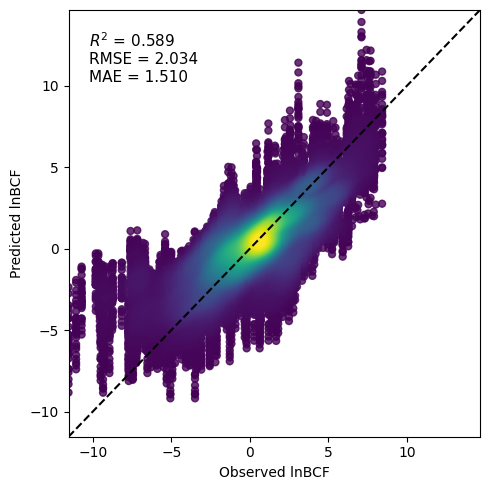

In [8]:
from scipy.stats import gaussian_kde
# ---------------------------
# Overall 20-shot metrics
# ---------------------------
overall_pred = np.array(overall_pred)
overall_obs = np.array(overall_obs)

r2 = r2_score(overall_obs, overall_pred)
rmse = np.sqrt(mean_squared_error(overall_obs, overall_pred))
mae = mean_absolute_error(overall_obs, overall_pred)

print('\nOverall 20-shot')
print(f'R² = {r2:.3f}')
print(f'RMSE = {rmse:.3f}')
print(f'MAE = {mae:.3f}')

# ---------------------------
# Plot NC-style scatter
# ---------------------------
xy = np.vstack([overall_obs, overall_pred])
z = gaussian_kde(xy)(xy)

idx = z.argsort()
x = overall_obs[idx]
y = overall_pred[idx]
z = z[idx]

fig, ax = plt.subplots(figsize=(5,5))
sc = ax.scatter(x, y, c=z, s=25, alpha=0.8, cmap='viridis')
lims = [min(x.min(), y.min()), max(x.max(), y.max())]
ax.plot(lims, lims, '--', color='black', lw=1.5)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel('Observed lnBCF')
ax.set_ylabel('Predicted lnBCF')
ax.text(0.05, 0.95,
        f'$R^2$ = {r2:.3f}\nRMSE = {rmse:.3f}\nMAE = {mae:.3f}',
        transform=ax.transAxes,
        ha='left',
        va='top',
        fontsize=11)
plt.tight_layout()
plt.show()

In [ ]:
#Save detail / prediction files
detail_df = pd.DataFrame(detail_results)
pred_df   = pd.DataFrame(pred_records)

detail_df.to_excel('../../dataset/FewShot/FewShot_Detail.xlsx', index=False)
pred_df.to_excel('../../dataset/FewShot/FewShot_Predictions.xlsx', index=False)

In [ ]:
study_median_df = (
    detail_df
    .groupby(['Reference', 'shot'])
    .agg(
        Median_R2=('R2', 'median'),
        Median_RMSE=('RMSE', 'median'),
        Median_MAE=('MAE', 'median'),
        Mean_R2=('R2', 'mean'),
        Std_R2=('R2', 'std'),
        N=('R2', 'count')
    )
    .reset_index()
    .sort_values(['Reference', 'shot'])
)

# 保存
study_median_df.to_excel('../../dataset/FewShot/EachStudy_Shot_MedianMetrics.xlsx', index=False)

print(study_median_df)

    Reference  shot  Median_R2  Median_RMSE  Median_MAE   Mean_R2    Std_R2  \
0           1     0   0.706336     0.835418    0.683702  0.706336       NaN   
1           1     5   0.562248     1.048431    0.855439  0.441634  0.350719   
2           1    10   0.666889     0.911473    0.770480  0.619479  0.112126   
3           1    20   0.679188     0.850176    0.724345  0.659833  0.103621   
4           2     0   0.024855     1.348399    1.058783  0.024855       NaN   
5           2     5   0.023710     1.335814    1.077162 -0.120820  0.582539   
6           2    10   0.292845     1.157985    0.935156  0.197218  0.265685   
7           2    20   0.356065     1.101423    0.903388  0.321340  0.126060   
8           3     0  -0.558199     2.649391    2.273655 -0.558199       NaN   
9           3     5   0.478939     1.539930    1.281610  0.299514  0.411346   
10          3    10   0.528474     1.475780    1.202594  0.378493  0.310921   
11          3    20   0.567686     1.406907    1.149

Sample size alone does not guarantee adaptation performance; feature diversity is equally important.
While most studies showed marked improvement after few-shot calibration, two studies exhibited limited gains, indicating heterogeneous adaptability across domains.
The limited improvement may arise from strong domain shifts, low within-study variance, or study-specific mechanisms not captured by the current predictor set. These cases highlight the importance of expanding training coverage and incorporating additional mechanistic variables.

In [18]:
# ============================================================
# Overall few-shot curve
# ============================================================

summary_df = (

    detail_df
    .groupby('shot')
    .agg(

        Median_R2=('R2', 'median'),
        Mean_R2=('R2', 'mean'),
        Std_R2=('R2', 'std'),

        Median_RMSE=('RMSE', 'median'),
        Median_MAE=('MAE', 'median'),

        N=('R2', 'count')
    )
    .reset_index()
)

print(summary_df)

   shot  Median_R2   Mean_R2    Std_R2  Median_RMSE  Median_MAE    N
0     0   0.249222 -0.096924  0.784613     1.564095    1.285385   11
1     5   0.211304 -0.059287  0.922413     1.533501    1.212830  330
2    10   0.451587  0.365790  0.315063     1.437616    1.152931  300
3    20   0.533348  0.474394  0.169643     1.359748    1.062116  270


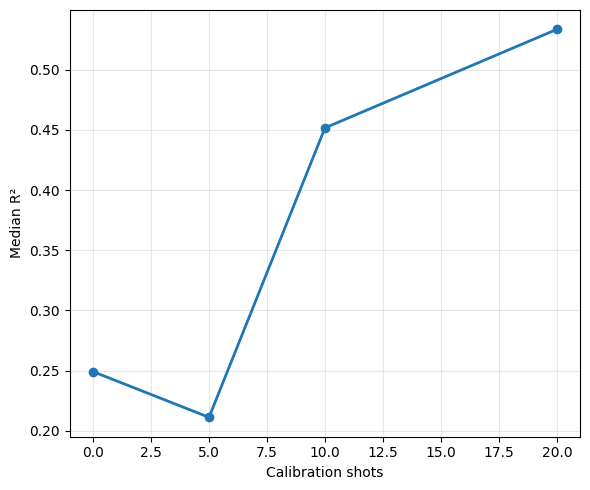

In [ ]:
# ============================================================
# Plot
# ============================================================

plt.figure(figsize=(6,5))

plt.plot(
    summary_df['shot'],
    summary_df['Median_R2'],
    marker='o',
    linewidth=2
)

plt.xlabel('Calibration shots')

plt.ylabel('Median R²')

#plt.title('Few-shot Cross-study Calibration')

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    '../../Fig/FewShot_OverallCurve.png',
    dpi=600
)

plt.savefig(
    '../../Fig/FewShot_OverallCurve.pdf',
    dpi=600
)

plt.show()

   shot  Median_R2   Mean_R2    Std_R2     Q1_R2     Q3_R2    Min_R2  \
0     0   0.249222 -0.096924  0.784613 -0.578093  0.475580 -1.797330   
1     5   0.211304 -0.059287  0.922413 -0.182362  0.478426 -6.414099   
2    10   0.451587  0.365790  0.315063  0.268414  0.556579 -2.426040   
3    20   0.533348  0.474394  0.169643  0.351200  0.599352 -0.117231   

     Max_R2    N  
0  0.706336   11  
1  0.742752  330  
2  0.780437  300  
3  0.797827  270  


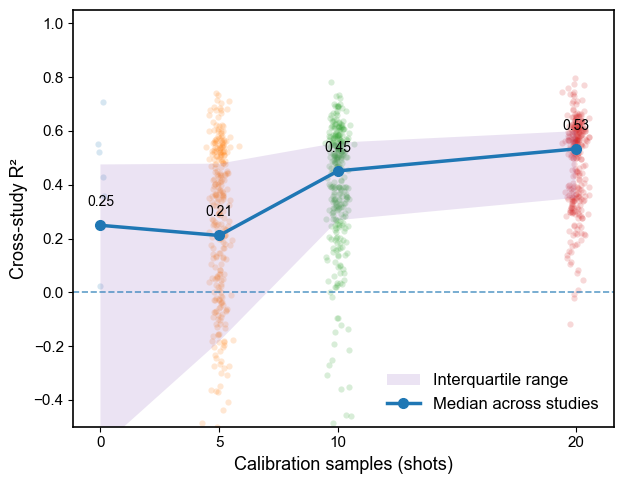

In [ ]:
# ============================================================
# Few-shot transferability summary plot (NC style)
# ============================================================

# ============================================================
# Aggregate statistics
# ============================================================

summary_df = (

    detail_df
    .groupby('shot')
    .agg(
        Median_R2=('R2', 'median'),
        Mean_R2=('R2', 'mean'),
        Std_R2=('R2', 'std'),
        Q1_R2=('R2', lambda x: np.percentile(x, 25)),
        Q3_R2=('R2', lambda x: np.percentile(x, 75)),
        Min_R2=('R2', 'min'),
        Max_R2=('R2', 'max'),
        N=('R2', 'count')
    )
    .reset_index()
    .sort_values('shot')
)

print(summary_df)

# ============================================================
# Keep only major shots for clean visualization
# ============================================================

major_shots = [0, 5, 10, 20]

summary_plot = summary_df[
    summary_df['shot'].isin(major_shots)
]

detail_plot = detail_df[
    detail_df['shot'].isin(major_shots)
]

# ============================================================
# Plot settings (Nature Communications style)
# ============================================================

plt.rcParams.update({

    'font.family': 'Arial',

    'font.size': 12,

    'axes.linewidth': 1.2,

    'axes.labelsize': 13,

    'axes.titlesize': 15,

    'xtick.labelsize': 11,

    'ytick.labelsize': 11,

    'legend.fontsize': 10
})

# ============================================================
# Create figure
# ============================================================

fig, ax = plt.subplots(figsize=(6.4, 5.0))

# ============================================================
# Scatter individual repeats
# ============================================================

rng = np.random.RandomState(42)

for shot in major_shots:

    tmp = detail_plot[
        detail_plot['shot'] == shot
    ]

    # jitter
    x_jitter = rng.normal(
        loc=shot,
        scale=0.22,
        size=len(tmp)
    )

    ax.scatter(

        x_jitter,

        tmp['R2'],

        s=20,

        alpha=0.18,

        linewidth=0,

        zorder=1
    )

# ============================================================
# Interquartile range band
# ============================================================

ax.fill_between(

    summary_plot['shot'],

    summary_plot['Q1_R2'],

    summary_plot['Q3_R2'],

    alpha=0.18,

    zorder=2,

    label='Interquartile range'
)

# ============================================================
# Median trajectory
# ============================================================

ax.plot(

    summary_plot['shot'],

    summary_plot['Median_R2'],

    marker='o',

    markersize=7,

    linewidth=2.5,

    zorder=3,

    label='Median across studies'
)

# ============================================================
# Baseline
# ============================================================

ax.axhline(

    0,

    linestyle='--',

    linewidth=1.2,

    alpha=0.7
)

# ============================================================
# Add annotations
# ============================================================

for _, row in summary_plot.iterrows():

    ax.text(

        row['shot'],

        row['Median_R2'] + 0.06,

        f"{row['Median_R2']:.2f}",

        ha='center',

        va='bottom',

        fontsize=10
    )

# ============================================================
# Labels
# ============================================================

ax.set_xlabel(
    'Calibration samples (shots)'
)

ax.set_ylabel(
    'Cross-study R²'
)

# ax.set_title(
#     'Few-shot calibration improves model transferability'
# )

# ============================================================
# X ticks
# ============================================================

ax.set_xticks(major_shots)

# ============================================================
# Y limits
# 避免极端离群值压缩主体区域
# ============================================================

ax.set_ylim(-0.5, 1.05)

# ============================================================
# Remove top/right spines
# ============================================================

# ax.spines['top'].set_visible(False)

# ax.spines['right'].set_visible(False)

# ============================================================
# Legend
# ============================================================

ax.legend(
    frameon=False,
    loc='lower right',
    fontsize=12
)

# ============================================================
# Layout
# ============================================================

plt.tight_layout()

# ============================================================
# Save
# ============================================================

plt.savefig(
    '../../Fig/FewShot_OverallCurve_NC.png',
    dpi=600,
    bbox_inches='tight'
)

plt.savefig(
    '../../Fig/FewShot_OverallCurve_NC.pdf',
    dpi=600,
    bbox_inches='tight'
)

plt.show()

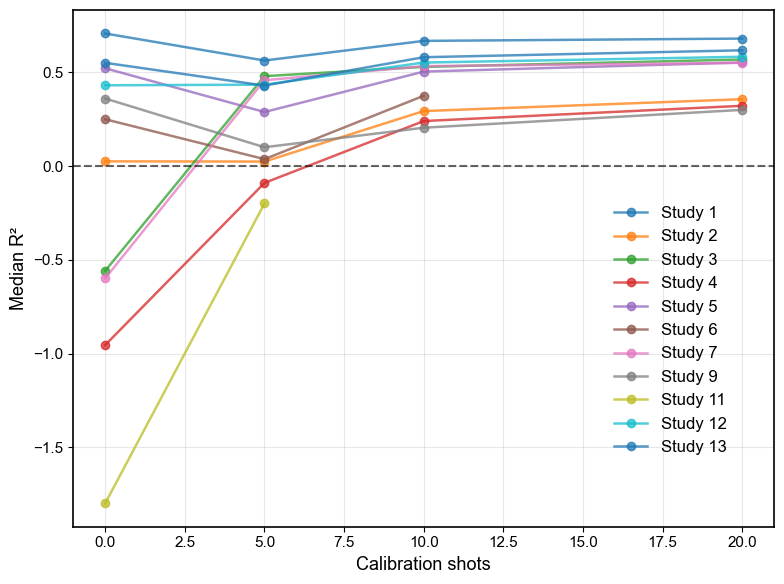

In [ ]:
# ============================================================
# Study-specific trajectory with labels
# ============================================================

study_curve = (
    detail_df
    .groupby(['Reference', 'shot'])['R2']
    .median()
    .reset_index()
)

# ------------------------------------------------------------
# Figure 1: all studies
# ------------------------------------------------------------

plt.figure(figsize=(8,6))

for g in study_curve['Reference'].unique():

    tmp = study_curve[
        study_curve['Reference'] == g
    ].sort_values('shot')

    plt.plot(
    tmp['shot'],
    tmp['R2'],
    marker='o',
    linewidth=1.8,
    alpha=0.75,
    label=f'Study {g}'
)


# baseline
plt.axhline(0, ls='--', c='black', alpha=0.6)

plt.xlabel('Calibration shots', fontsize=13)

plt.ylabel('Median R²', fontsize=13)

# plt.title(
#     'Study-specific Few-shot Calibration Trajectories',
#     fontsize=14
# )

plt.grid(alpha=0.3)

plt.tight_layout()

# plt.savefig(
#     '../../Fig/FewShot_StudyTrajectory_Label.png',
#     dpi=600
# )

# plt.savefig(
#     '../../Fig/FewShot_StudyTrajectory_Label.pdf',
#     dpi=600
# )
plt.legend(
    bbox_to_anchor=(0.75, 0.65),
    loc='upper left',
    fontsize=12,
    frameon=False
)
plt.show()

Difficult studies: [3, 4, 7, 11]


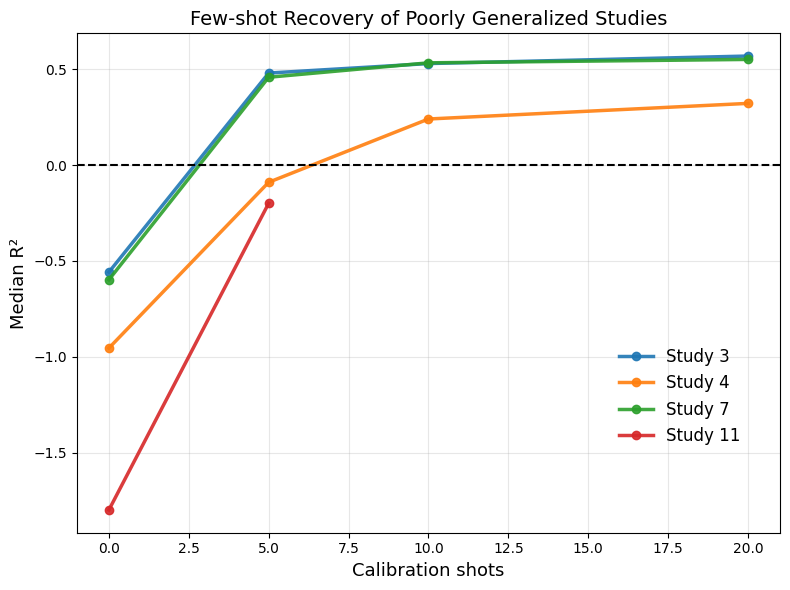

In [ ]:
# ============================================================
# Figure 2: only difficult studies (0-shot R2 < 0)
# ============================================================

# 找出0-shot表现差的研究
bad_studies = (
    study_curve[study_curve['shot'] == 0]
    .query('R2 < 0')['Reference']
    .tolist()
)

print('Difficult studies:', bad_studies)

plt.figure(figsize=(8,6))

for g in bad_studies:

    tmp = study_curve[
        study_curve['Reference'] == g
    ].sort_values('shot')

    plt.plot(
        tmp['shot'],
        tmp['R2'],
        marker='o',
        linewidth=2.5,
        alpha=0.9,
        label=f'Study {g}'
    )


plt.axhline(0, ls='--', c='black')

plt.xlabel('Calibration shots', fontsize=13)

plt.ylabel('Median R²', fontsize=13)

plt.title(
    'Few-shot Recovery of Poorly Generalized Studies',
    fontsize=14
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    '../../Fig/FewShot_BadStudies.png',
    dpi=600
)

plt.savefig(
    '../../Fig/FewShot_BadStudies.pdf',
    dpi=600
)
plt.legend(
    bbox_to_anchor=(0.75, 0.4),
    loc='upper left',
    fontsize=12,
    frameon=False
)
plt.show()